# **AdaBoost (Adaptive Boost)**

`Adaboost` é um dos métodos mais populares de `Boosting`, que se refere a combinação de modelos de aprendizagem fracos para criar um modelo de aprendizagem forte. **A ideia central é criar modelos sequencialmente, cada um tentando corrigir o erro do modelo anterior**.

Amostras classificadas incorretamente recebem pesos maiores na próxima iteração, forçando o modelo a aprender com os casos difíceis.

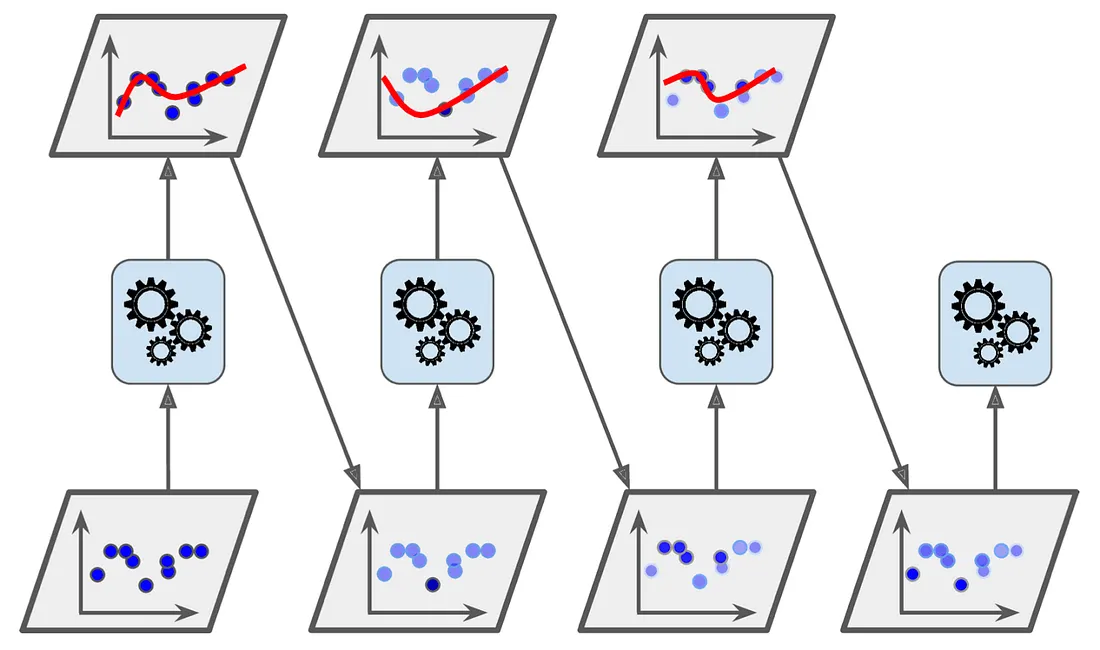

## **Exemplo práticos**

#### **Importando bibliotecas**

In [945]:
# Datasets
from sklearn import datasets

# Separação treino e teste
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas de avaliação
from sklearn.metrics import accuracy_score, confusion_matrix

#### **Carregando o dataset**

In [946]:
dataset = datasets.load_breast_cancer()

In [947]:
# Features:
dataset.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [948]:
# Targets:
dataset.target_names

array(['malignant', 'benign'], dtype='<U9')

In [949]:
X = dataset.data
print(f'X shape = {X.shape}')

X shape = (569, 30)


In [950]:
y = dataset.target
print(f'y shape = {y.shape}')

y shape = (569,)


In [951]:
print(f'Labels 0: {list(y).count(0)}')
print(f'Labels 1: {list(y).count(1)}')

Labels 0: 212
Labels 1: 357


#### **Divisão em treino e teste**

In [952]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

print(f'X_train shape = {X_train.shape}')
print(f'y_train shape = {y_train.shape}')
print(f'X_test shape = {X_test.shape}')
print(f'y_test shape = {y_test.shape}')

X_train shape = (381, 30)
y_train shape = (381,)
X_test shape = (188, 30)
y_test shape = (188,)


#### **Instânciando os modelos e avaliando as predições**

In [953]:
# Árvore de decisão:

decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [954]:
predict_decision_tree = decision_tree.predict(X_train)
print(f'Model: Decison Tree | Accuracy train: {accuracy_score(y_train, predict_decision_tree):.4%}')

Model: Decison Tree | Accuracy train: 99.4751%


In [955]:
predict_decision_tree = decision_tree.predict(X_test)
print(f'Model: Decison Tree | Accuracy test: {accuracy_score(y_test, predict_decision_tree):.4%}')

Model: Decison Tree | Accuracy test: 91.4894%


Podemos observar que o modelo pode está sofrendo **overfitting**, pois o modelo se saí muito bem nos treinos mas não generaliza bem para os testes, problema muito comum em árvores de decisão isoladas.

In [956]:
print(f'Confusion matriz: \n{confusion_matrix(y_test, predict_decision_tree)}')

Confusion matriz: 
[[ 64   6]
 [ 10 108]]


In [957]:
# AdaBoost:

dt = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_boost = AdaBoostClassifier(estimator=dt, n_estimators=50, learning_rate=0.05)
ada_boost.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [958]:
predict_ada_boost = ada_boost.predict(X_train)
print(f'Model: Ada boost | Accuracy train: {accuracy_score(y_train, predict_ada_boost):.4%}')

Model: Ada boost | Accuracy train: 96.5879%


In [959]:
predict_ada_boost = ada_boost.predict(X_test)
print(f'Model: Ada Boost | Accuracy test: {accuracy_score(y_test, predict_ada_boost):.4%}')

Model: Ada Boost | Accuracy test: 93.0851%


In [960]:
print(f'Confusion matriz: \n{confusion_matrix(y_test, predict_ada_boost)}')

Confusion matriz: 
[[ 63   7]
 [  6 112]]


## **Referências:**
- https://pedroazambuja.medium.com/adaboost-adaptive-boosting-dbbec150fced
- https://medium.com/equals-lab/uma-breve-introdu%C3%A7%C3%A3o-ao-algoritmo-de-machine-learning-gradient-boosting-utilizando-a-biblioteca-311285783099